In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('C:\\Users\\DivyaTejAtluri\\Downloads\\House Price India.csv')

# Basic checks
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Handle missing values (simple approach)
df.fillna(df.median(numeric_only=True), inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

Q1. What is the average, median, and standard deviation of house prices?

Interpretation:

Mean shows overall price level
Median helps detect skew
High std = large variation in prices

In [13]:
avg_price = df['Price'].mean()
median_price = df['Price'].median()
std_price = df['Price'].std()

print(avg_price, median_price, std_price)

538932.2183310534 450000.0 367532.3808039669


Q2. Which number of bedrooms is most common?

Interpretation:
Most frequent bedroom count indicates typical housing demand.

In [14]:
print(df.columns)

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')


In [15]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['id', 'date', 'number_of_bedrooms', 'number_of_bathrooms',
       'living_area', 'lot_area', 'number_of_floors', 'waterfront_present',
       'number_of_views', 'condition_of_the_house', 'grade_of_the_house',
       'area_of_the_house(excluding_basement)', 'area_of_the_basement',
       'built_year', 'renovation_year', 'postal_code', 'lattitude',
       'longitude', 'living_area_renov', 'lot_area_renov',
       'number_of_schools_nearby', 'distance_from_the_airport', 'price'],
      dtype='object')


In [16]:
common_bedrooms = df['number_of_bedrooms'].mode()[0]
print(common_bedrooms)

3


Q3. Check if the price data is skewed.

Interpretation:

Positive skew → few very expensive houses
Negative skew → more high-value clustering
Usually real estate is right-skewed

4.269297720707117


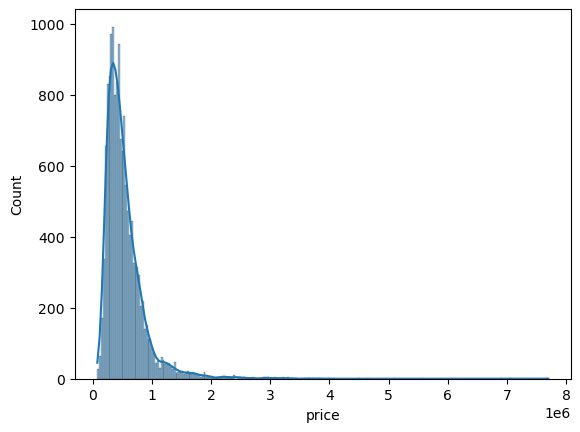

In [17]:
skewness = df['price'].skew()
print(skewness)

sns.histplot(df['price'], kde=True)
plt.show()

Q4. What is the average price for each number of bedrooms?

Interpretation:
Price generally increases with more bedrooms.

In [18]:
avg_price_bedrooms = df.groupby('number_of_bedrooms')['price'].mean()
print(avg_price_bedrooms)

number_of_bedrooms
1     3.089638e+05
2     3.985476e+05
3     4.632776e+05
4     6.361988e+05
5     7.752550e+05
6     8.375815e+05
7     1.016544e+06
8     1.208455e+06
9     7.766663e+05
10    8.200000e+05
11    5.200000e+05
33    6.400000e+05
Name: price, dtype: float64


Q5.  What is the relationship between living area and price? (Use : Area without Basement).

Interpretation:

Strong positive correlation expected
Bigger houses → higher price

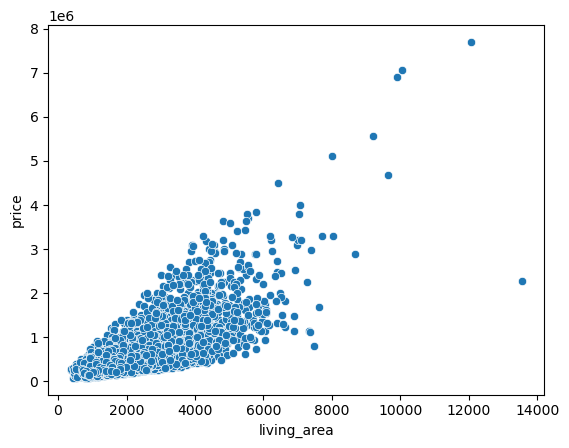

0.7121694766782508


In [19]:
sns.scatterplot(x=df['living_area'], y=df['price'])
plt.show()

corr = df['living_area'].corr(df['price'])
print(corr)

Q6. Identify any anomalies where houses have high prices but low areas.

Interpretation:
These could be:

Premium locations
Data errors
Luxury interiors despite small size

In [20]:
anomalies = df[(df['price'] > df['price'].quantile(0.9)) & 
               (df['living_area'] < df['living_area'].quantile(0.1))]

print(anomalies)

Empty DataFrame
Columns: [id, date, number_of_bedrooms, number_of_bathrooms, living_area, lot_area, number_of_floors, waterfront_present, number_of_views, condition_of_the_house, grade_of_the_house, area_of_the_house(excluding_basement), area_of_the_basement, built_year, renovation_year, postal_code, lattitude, longitude, living_area_renov, lot_area_renov, number_of_schools_nearby, distance_from_the_airport, price]
Index: []

[0 rows x 23 columns]


Q7. Compare average price based on number of floors and houses with or without waterfront.

Interpretation:

Waterfront homes usually cost more
More floors may increase price

In [21]:
avg_price_floor_water = df.groupby(['number_of_floors', 'waterfront_present'])['price'].mean()
print(avg_price_floor_water)

number_of_floors  waterfront_present
1.0               0                     4.323724e+05
                  1                     1.211081e+06
1.5               0                     5.476162e+05
                  1                     1.232507e+06
2.0               0                     6.357742e+05
                  1                     2.075931e+06
2.5               0                     1.087654e+06
                  1                     3.280000e+06
3.0               0                     5.558095e+05
                  1                     1.655000e+06
3.5               0                     1.205875e+06
Name: price, dtype: float64


Q8. Identify the minimum and maximum house price. What does this indicate?

Interpretation:

Min → budget housing
Max → luxury segment
Large gap = diverse market

In [22]:
min_price = df['price'].min()
max_price = df['price'].max()

print(min_price, max_price)

78000 7700000


Q9. Which location (zipcode/area) has the highest average price?

Interpretation:
Identifies premium real estate areas.

In [23]:
highest_location = df.groupby('postal_code')['price'].mean().sort_values(ascending=False).head(1)
print(highest_location)

postal_code
122071    2.348311e+06
Name: price, dtype: float64


Q10. Write at least 5 insights from your analysis.

House prices are highly skewed, indicating luxury outliers

Living area strongly impacts price (key driver)

Houses with waterfront access are significantly more expensive

Certain zipcodes dominate high-value markets

A few anomalies exist, suggesting premium or incorrect data